# PyTorch — Chapter 8: Creating a Training Loop for Your Models


## 1. Các thành phần của một training loop

- Dữ liệu nên tách thành **training set** để chạy gradient descent và **test set** để đo model khái quát hoá tốt đến đâu.
- **Overfitting**: khớp rất tốt trên train nhưng kém hẳn trên test. **Underfitting**: khớp kém ngay cả trên train. Cả hai đều không mong muốn.
- Một **epoch** = một lượt đi hết training set, chia thành nhiều **batch**; mỗi batch là một bước forward pass + backward pass + cập nhật trọng số.
- Ví dụ tách dữ liệu: dataset Pima có 768 mẫu → lấy 700 mẫu đầu làm `Xtrain/ytrain`, 68 mẫu còn lại làm `Xtest/ytest`.

## 2. Thu thập số liệu trong lúc huấn luyện

Mở rộng training loop để lưu lại: loss mỗi bước, accuracy trên batch train mỗi bước, và accuracy trên test set ở cuối mỗi epoch — 3 danh sách `train_loss`, `train_acc`, `test_acc`.

- Vì `train_acc` được ghi mỗi **bước** (nhiều lần/epoch) còn `test_acc` chỉ ghi mỗi **epoch**, cần phải lấy **trung bình** `train_acc` theo từng epoch trước khi vẽ cùng biểu đồ với `test_acc`.
- Kỹ thuật: checkpointing (lưu model giữa chừng) và early stopping (dừng sớm khi test accuracy không cải thiện).

## 3. Dùng tqdm để hiển thị tiến độ

- `tqdm.trange(n, ...)` lặp và hiện thanh tiến độ động.
- `bar.set_description()` đặt nhãn (VD "Epoch 3"), `bar.set_postfix(loss=..., acc=...)` hiện số liệu ngay trên thanh tiến độ, cập nhật real-time.
- `tqdm.tqdm(list, ...)` dùng khi muốn lặp qua một list có sẵn.


## 4. Vận dụng


**8.1** — Nạp dữ liệu và tách thành train/test set

In [1]:
import numpy as np
import torch

# load the dataset
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# split the dataset into training and test sets
Xtrain = X[:700]
ytrain = y[:700]
Xtest = X[700:]
ytest = y[700:]


**8.2** — Khởi tạo model, loss function và optimizer

In [2]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

# loss function and optimizer
loss_fn = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)


Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


**8.5** — Code hoàn chỉnh: huấn luyện + đánh giá (⚠️ đánh giá trên toàn bộ X/y, không riêng test set)

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# load the dataset
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# split the dataset into training and test sets
Xtrain = X[:700]
ytrain = y[:700]
Xtest = X[700:]
ytest = y[700:]

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

# loss function and optimizer
loss_fn = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        start = i * batch_size
        # take a batch
        Xbatch = Xtrain[start:start+batch_size]
        ybatch = ytrain[start:start+batch_size]
        # forward pass
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

# evaluate trained model with test set
with torch.no_grad():
    y_pred = model(X)
accuracy = (y_pred.round() == y).float().mean()
print("Accuracy {:.2f}".format(accuracy * 100))


Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)
Accuracy 71.35


**8.8** — Code hoàn chỉnh: huấn luyện có thu thập số liệu + vẽ biểu đồ loss/accuracy

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)
epoch 0 step 0 loss 5.771231651306152 accuracy 0.4000000059604645
epoch 0 step 1 loss 9.223913192749023 accuracy 0.4000000059604645
epoch 0 step 2 loss 2.0183863639831543 accuracy 0.6000000238418579
epoch 0 step 3 loss 4.389862537384033 accuracy 0.4000000059604645
epoch 0 step 4 loss 3.824028730392456 accuracy 0.20000000298023224
epoch 0 step 5 loss 4.471389293670654 accuracy 0.4000000059604645
epoch 0 step 6 loss 1.4841854572296143 accuracy 0.5
epoch 0 step 7 loss 1.8944618701934814 accuracy 0.4000000059604645
epoch 0 step 8 loss 2.0860791206359863 accuracy 0.4000000059604645
epoch 0 step 9 loss 1.9922420978546143 accuracy 0.5
epoch 0 step 10 loss 1.9356393814086914 accuracy 0.4000000059604645
epoch 0 step 11 loss 5.773273944854736 accuracy 0.20000000298023224

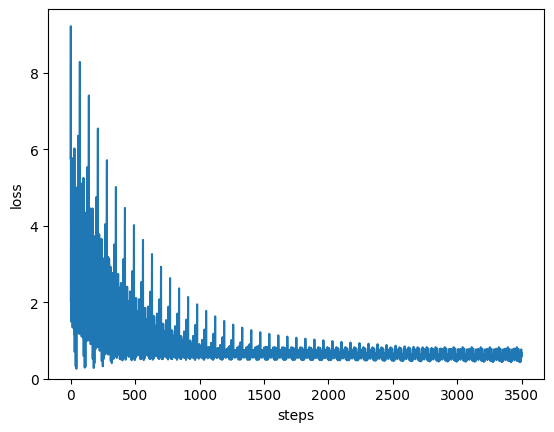

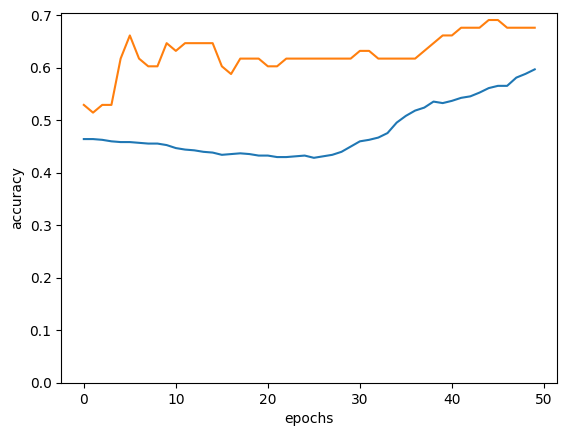

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# load the dataset
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
# split into input (X) and output (y) variables
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# split the dataset into training and test sets
Xtrain = X[:700]
ytrain = y[:700]
Xtest = X[700:]
ytest = y[700:]

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

# loss function and optimizer
loss_fn = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

# collect statistics
train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        # take a batch
        start = i * batch_size
        Xbatch = Xtrain[start:start+batch_size]
        ybatch = ytrain[start:start+batch_size]
        # forward pass
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        acc = (y_pred.round() == ybatch).float().mean()
        # store metrics
        train_loss.append(float(loss))
        train_acc.append(float(acc))
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()
        # print progress
        print(f"epoch {epoch} step {i} loss {loss} accuracy {acc}")
    # evaluate model at end of epoch
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"End of {epoch}, accuracy {acc}")

# Plot the loss metrics
plt.plot(train_loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.ylim(0)
plt.show()

# plot the accuracy metrics
avg_train_acc = []
for i in range(n_epochs):
    start = i * batch_size
    average = sum(train_acc[start:start+batches_per_epoch]) / batches_per_epoch
    avg_train_acc.append(average)

plt.plot(avg_train_acc, label="train")
plt.plot(test_acc, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0)
plt.show()


**8.11** — Code hoàn chỉnh: huấn luyện với thanh tiến độ tqdm

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

# load the dataset
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
# split into input (X) and output (y) variables
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# split the dataset into training and test sets
Xtrain = X[:700]
ytrain = y[:700]
Xtest = X[700:]
ytest = y[700:]

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

# loss function and optimizer
loss_fn = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

# collect statistics
train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # take a batch
            start = i * batch_size
            Xbatch = Xtrain[start:start+batch_size]
            ybatch = ytrain[start:start+batch_size]
            # forward pass
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            acc = (y_pred.round() == ybatch).float().mean()
            # store metrics
            train_loss.append(float(loss))
            train_acc.append(float(acc))
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(
                loss=float(loss),
                acc=f"{float(acc)*100:.2f}%"
            )
    # evaluate model at end of epoch
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"End of {epoch}, accuracy {acc}")


ModuleNotFoundError: No module named 'tqdm'